# Weather vs Health Data Analysis



In [68]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
BASE_PATH = "/content/drive/MyDrive/ADS_CW_Data/"

# WHO datasets
TB_PATH = BASE_PATH + "tuberculosis_p100k.csv"
MALARIA_PATH = BASE_PATH + "malaria_cases_p1000_at_risk.csv"
AIR_PATH = BASE_PATH + "air_pollution_DALYS_p100k.csv"

# Weather folder (all CSV files)
WEATHER_FOLDER = BASE_PATH + "weather_data/"


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [71]:
# Load WHO datasets
tb_df = pd.read_csv(TB_PATH)
malaria_df = pd.read_csv(MALARIA_PATH)
air_df = pd.read_csv(AIR_PATH)

def clean_who_data(df, value_name):
    df = df[['Location', 'Period', 'FactValueNumeric']]
    df = df.rename(columns={
        'Location': 'country',
        'Period': 'year',
        'FactValueNumeric': value_name
    })
    df = df.dropna()
    df['year'] = df['year'].astype(int)
    return df

tb = clean_who_data(tb_df, 'tb_incidence')
def clean_malaria_data(df):
    df = df.copy()

    df = df[['Location', 'Period', 'FactValueNumeric']]

    df = df.rename(columns={
        'Location': 'country',
        'Period': 'year',
        'FactValueNumeric': 'malaria_incidence'
    })

    # Convert types first
    df['year'] = df['year'].astype(int)
    df['malaria_incidence'] = pd.to_numeric(df['malaria_incidence'], errors='coerce')

    # DO NOT DROP NaNs — replace with 0
    df['malaria_incidence'] = df['malaria_incidence'].fillna(0)

    return df


malaria = clean_malaria_data(malaria_df)
air = clean_who_data(air_df, 'air_pollution_dalys')

disease_df = tb.merge(malaria, on=['country','year'], how='outer') \
               .merge(air, on=['country','year'], how='outer')


print("Disease data shape:", disease_df.shape)
disease_df.head()


Disease data shape: (36097, 5)


,country,year,tb_incidence,malaria_incidence,air_pollution_dalys
0,Afghanistan,2000,148.0,84.48,NaN
1,Afghanistan,2001,175.0,83.83,NaN
2,Afghanistan,2002,197.0,83.79,NaN
3,Afghanistan,2003,215.0,70.81,NaN
4,Afghanistan,2004,228.0,39.41,NaN


In [72]:
print(data.columns)

Index(['Year', 'Month', 'Day', 'Hour', 'Temperature_K', 'Precipitation_m',
       'U_wind', 'V_wind', 'location', 'datetime', 'wind_speed'],
      dtype='object')


In [73]:
print(pd.read_csv(files[0]).columns)

Index(['1980', '1', '1.1', '0', '298.78', '3.7307e-06', '1.8268', '0.38965'], dtype='object')


In [74]:
from pathlib import Path
import pandas as pd
import numpy as np

# Path to your weather files
data_folder = Path(BASE_PATH + "weather_data/")
files = list(data_folder.glob("*.csv"))

print("Number of files:", len(files))
files[:5]


Number of files: 12


[PosixPath('/content/drive/MyDrive/ADS_CW_Data/weather_data/-33.5N_151E.csv'),
 PosixPath('/content/drive/MyDrive/ADS_CW_Data/weather_data/-33.9N_18.5E.csv'),
 PosixPath('/content/drive/MyDrive/ADS_CW_Data/weather_data/17.36N_78.5E.csv'),
 PosixPath('/content/drive/MyDrive/ADS_CW_Data/weather_data/18N_283.2E.csv'),
 PosixPath('/content/drive/MyDrive/ADS_CW_Data/weather_data/40.75N_286.01E.csv')]

In [75]:
# Define column names
cols = ['Year','Month','Day','Hour','Temperature_K','Precipitation_m','U_wind','V_wind']

dfs = []

for f in files:
    df = pd.read_csv(f, header=None, names=cols)

    # Add location identifier
    df['location'] = f.stem

    # Create datetime
    df['datetime'] = pd.to_datetime(df[['Year','Month','Day','Hour']])

    # Compute wind speed
    df['wind_speed'] = np.sqrt(df['U_wind']**2 + df['V_wind']**2)

    dfs.append(df)

# Combine all weather data
data = pd.concat(dfs, ignore_index=True)

print("Weather data shape:", data.shape)
data.head()

Weather data shape: (4102560, 11)


,Year,Month,Day,Hour,Temperature_K,Precipitation_m,U_wind,V_wind,location,datetime,wind_speed
0,1980,1,1,0,298.78,0.000004,1.82680,0.38965,-33.5N_151E,1980-01-01 00:00:00,1.867893
1,1980,1,1,1,300.57,0.000003,1.54910,0.77725,-33.5N_151E,1980-01-01 01:00:00,1.733156
2,1980,1,1,2,301.18,0.000002,1.20190,0.79323,-33.5N_151E,1980-01-01 02:00:00,1.440062
3,1980,1,1,3,302.60,0.000003,0.91805,0.50503,-33.5N_151E,1980-01-01 03:00:00,1.047793
4,1980,1,1,4,302.81,0.000010,0.35183,0.45842,-33.5N_151E,1980-01-01 04:00:00,0.577870


In [76]:
# Create yearly weather aggregates
weather_annual = (
    data.groupby(['location', 'Year'])
    .agg({
        'Temperature_K': 'mean',
        'Precipitation_m': 'sum',   # sum, not mean
        'wind_speed': 'mean'
    })
    .reset_index()
    .rename(columns={
        'Year': 'year',
        'Temperature_K': 'temp_k',
        'Precipitation_m': 'precip_total',
        'wind_speed': 'wind_ms^-1'
    })
)

# Optional: convert precipitation to mm (more interpretable)
weather_annual['precip_mm'] = weather_annual['precip_total'] * 1000

weather_annual.head()

,location,year,temp_k,precip_total,wind_ms^-1,precip_mm
0,-33.5N_151E,1980,287.157984,0.707110,2.472914,707.110313
1,-33.5N_151E,1981,286.577546,0.846976,2.549778,846.975568
2,-33.5N_151E,1982,286.420664,0.755222,2.250528,755.222314
3,-33.5N_151E,1983,286.385063,1.176225,2.404842,1176.224504
4,-33.5N_151E,1984,285.725551,1.050669,2.404201,1050.668700


In [77]:
# Map locations to countries
location_to_country = {
    '-33.5N_151E': 'Australia',
    '-33.9N_18.5E': 'South Africa',
    '17.36N_78.5E': 'India',
    '18N_283.2E': 'Jamaica',
    '40.75N_286.01E': 'United States of America',
    '41.9N_12.46E': 'Italy',
    '43.28N_5.39E': 'France',
    '43.64N_280.63E': 'Canada',
    '51.03N_245.94E': 'Canada',
    '51.5N_359.9E': 'United Kingdom',
    '58.76N_265.83E': 'Canada',
    '59.92N_10.75E': 'Norway',
}

weather_annual['country'] = weather_annual['location'].map(location_to_country)

print("Unmapped:", weather_annual[weather_annual['country'].isna()]['location'].unique())


Unmapped: []


In [78]:
# Combine datasets
combined_df = weather_annual.merge(
    disease_df,
    on=['country','year'],
    how='inner'
)
combined_df['malaria_incidence'] = combined_df['malaria_incidence'].fillna(0)
combined_df = combined_df.sort_values(['location','year'])

print("Combined shape:", combined_df.shape)
combined_df.head()


Combined shape: (1892, 10)


,location,year,temp_k,precip_total,wind_ms^-1,precip_mm,country,tb_incidence,malaria_incidence,air_pollution_dalys
0,-33.5N_151E,2000,286.232501,0.700822,2.444258,700.822301,Australia,6.8,0.0,NaN
1,-33.5N_151E,2001,286.318106,0.782661,2.448888,782.660874,Australia,6.3,0.0,NaN
2,-33.5N_151E,2002,286.436395,0.673745,2.374959,673.745476,Australia,6.4,0.0,NaN
3,-33.5N_151E,2003,286.210140,0.660138,2.428628,660.138011,Australia,5.9,0.0,NaN
4,-33.5N_151E,2004,286.447916,0.975059,2.369327,975.059403,Australia,6.6,0.0,NaN


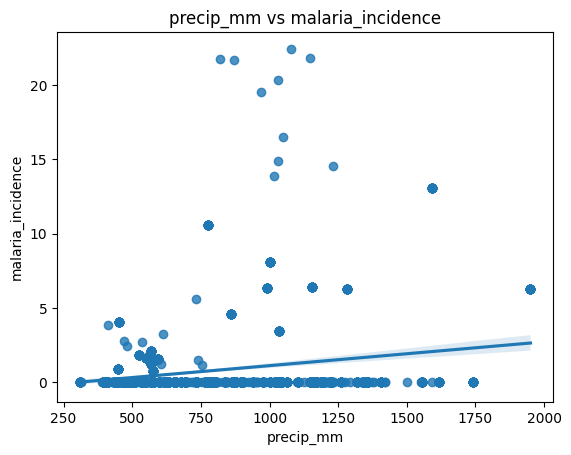

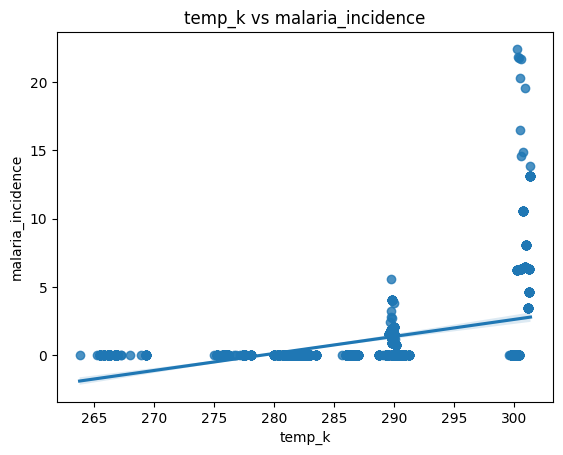

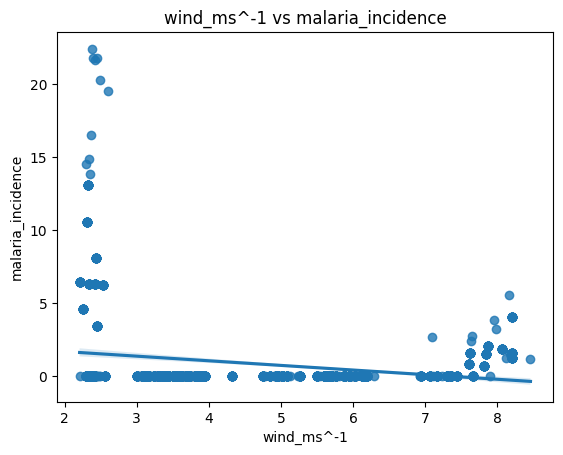

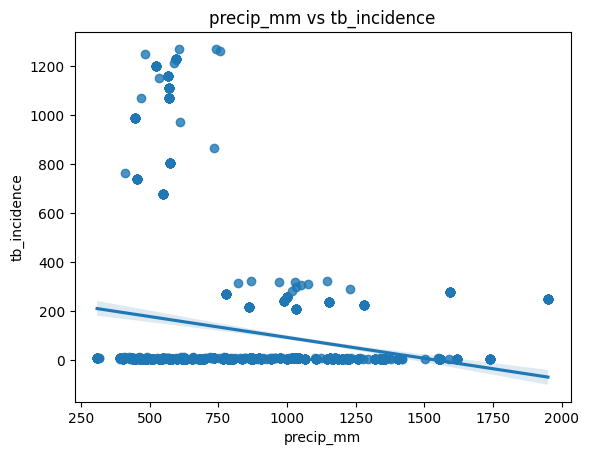

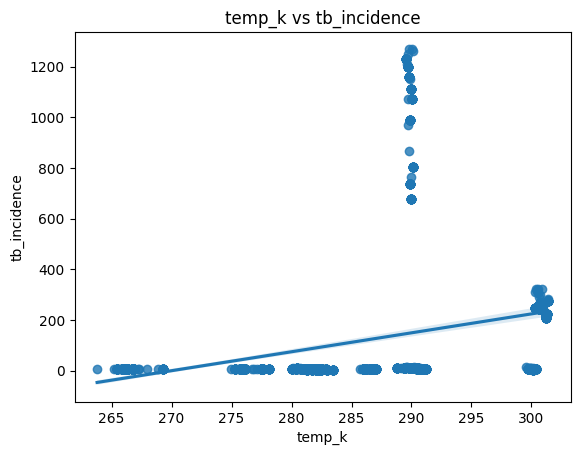

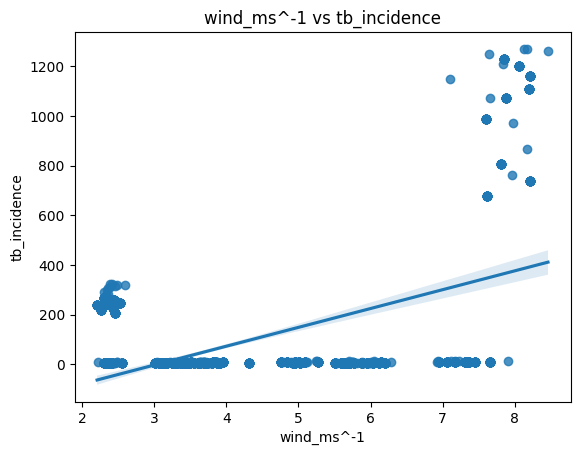

In [79]:
def reg_plot(df, x, y):
    plot_df = df[[x,y]].dropna()
    sns.regplot(data=plot_df, x=x, y=y)
    plt.title(f"{x} vs {y}")
    plt.show()

reg_plot(combined_df,'precip_mm','malaria_incidence')
reg_plot(combined_df,'temp_k','malaria_incidence')
reg_plot(combined_df,'wind_ms^-1','malaria_incidence')
reg_plot(combined_df,'precip_mm','tb_incidence')
reg_plot(combined_df,'temp_k','tb_incidence')
reg_plot(combined_df,'wind_ms^-1','tb_incidence')

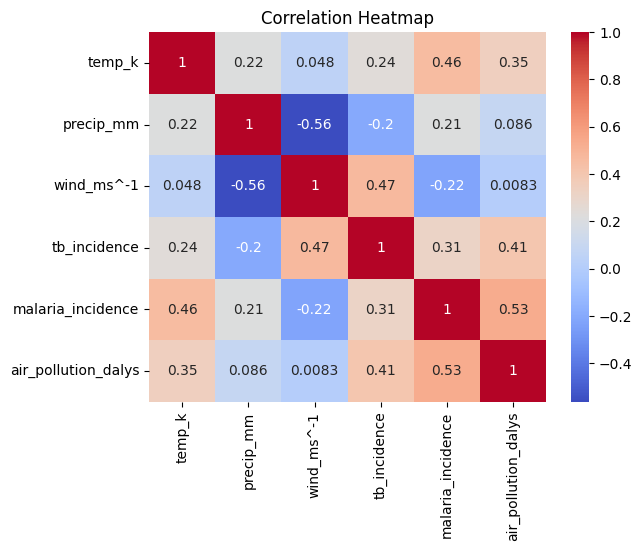

In [80]:
corr = combined_df[['temp_k','precip_mm','wind_ms^-1',
                         'tb_incidence','malaria_incidence','air_pollution_dalys']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [81]:
def run_regression(df, predictors, target):
    model_df = df[predictors+[target]].dropna()
    X = model_df[predictors]
    y = model_df[target]

    model = LinearRegression()
    model.fit(X,y)
    y_pred = model.predict(X)

    rmse = np.sqrt(mean_squared_error(y,y_pred))

    print("Target:",target)
    print("R2:", r2_score(y,y_pred))
    print("RMSE:", rmse)
    print("Coefficients:", dict(zip(predictors, model.coef_)))
    print()

run_regression(combined_df,['temp_k','precip_mm','wind_ms^-1'],'malaria_incidence')
run_regression(combined_df,['temp_k','precip_mm','wind_ms^-1'],'tb_incidence')
run_regression(combined_df,['temp_k','precip_mm','wind_ms^-1'],'air_pollution_dalys')


Target: malaria_incidence
R2: 0.2751097016224773
RMSE: 2.1967562213907943
Coefficients: {'temp_k': np.float64(0.13064010079778818), 'precip_mm': np.float64(-0.000347822779415439), 'wind_ms^-1': np.float64(-0.38568197763636103)}

Target: tb_incidence
R2: 0.27212657686259845
RMSE: 251.1918452612814
Coefficients: {'temp_k': np.float64(6.627399877385988), 'precip_mm': np.float64(0.017891886414867844), 'wind_ms^-1': np.float64(76.08841210190985)}

Target: air_pollution_dalys
R2: 0.11963516858214895
RMSE: 355.76296298928133
Coefficients: {'temp_k': np.float64(13.632940555533175), 'precip_mm': np.float64(0.009204950211538002), 'wind_ms^-1': np.float64(-0.6757976841807161)}

